In [3]:
import yfinance as yf
import pandas as pd

etfs = ["SCHD", "QQQ", "JEPQ"]

price_data = {}
div_data = {}

for etf in etfs:
    ticker = yf.Ticker(etf)
    
    df = ticker.history(start="2020-01-01")
    if df.empty:
        continue

    price_data[etf] = df["Close"]

    div = ticker.dividends
    div_data[etf] = div

price_df = pd.DataFrame(price_data)

# Daily returns
returns_df = price_df.pct_change().dropna()

returns_df.head()

# Cumulative returns
cumulative_returns = (1 + returns_df).cumprod()

cumulative_returns.head()

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

monthly_returns = price_df.resample('ME').ffill().pct_change()

monthly_returns.head()

monthly_returns['Year'] = monthly_returns.index.year
monthly_returns['Month'] = monthly_returns.index.month

pivot_qqq = monthly_returns.pivot_table(
    values='QQQ',
    index='Year',
    columns='Month'
)
pivot_schd = monthly_returns.pivot_table(
    values='SCHD',
    index='Year',
    columns='Month'
)
pivot_jepq = monthly_returns.pivot_table(
    values='JEPQ',
    index='Year',
    columns='Month'
)

import seaborn as sns
import matplotlib.pyplot as plt

# Total Return (Dividend Included)

total_return_df = pd.DataFrame()

for etf in etfs:
    price = price_df[etf]

    # Dividend data
    div = div_data[etf]
    div = div.reindex(price.index, fill_value=0)

    # Dividend yield
    dividend_yield = div / price

    # Price return
    price_return = price.pct_change()

    # Total return (price + dividend)
    total_return = price_return + dividend_yield

    total_return_df[etf] = total_return

# Cumulative total return
cumulative_total_return = (1 + total_return_df).cumprod()

## 📌 Total Return with Reinvestment

In this step, ETF performance is analyzed by assuming that dividends are reinvested.

Unlike the previous step, where dividend yield was simply added to price returns, this approach reflects the compounding effect of reinvestment.

---

## ❗ Why Reinvestment Matters

Reinvesting dividends allows investors to benefit from compounding, which can significantly impact long-term returns.

This is especially important for dividend-paying ETFs.

---

## 🎯 Objective

The goal of this step is to:

- Simulate total return with dividend reinvestment  
- Compare results with previous methods  
- Understand the impact of compounding on ETF performance  

---

## ⚙️ Methodology

Total return is calculated by:

- Adding dividend yield to daily returns  
- Compounding returns over time  

This approach better reflects real investment behavior compared to simple addition.

---

## 📊 Expected Insight

This analysis aims to show that reinvested dividends can significantly enhance long-term returns.

## 🧠 Implementation Overview

In this step, total return is calculated under the assumption that dividends are reinvested.

In [2]:
# Total Return with Reinvestment

reinvested_return_df = total_return_df.copy()

cumulative_reinvested_return = (1 + reinvested_return_df).cumprod()

cumulative_reinvested_return.head()

,SCHD,QQQ,JEPQ
Date,,,
2020-01-02 00:00:00-05:00,NaN,NaN,NaN
2020-01-03 00:00:00-05:00,0.992767,0.990840,NaN
2020-01-06 00:00:00-05:00,0.992595,0.997224,NaN
2020-01-07 00:00:00-05:00,0.991217,0.997085,NaN
2020-01-08 00:00:00-05:00,0.995006,1.004580,NaN


## 📊 Reinvested Return Visualization

In this step, reinvested cumulative total returns are visualized for each ETF.

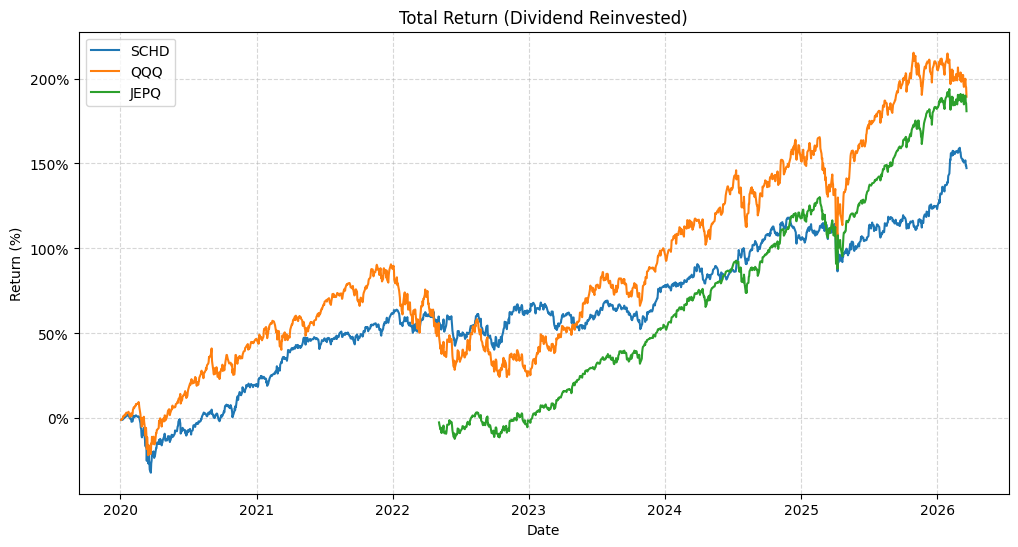

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(12,6))

for etf in cumulative_reinvested_return.columns:
    plt.plot(
        cumulative_reinvested_return.index,
        cumulative_reinvested_return[etf] - 1,
        label=etf
    )

plt.title("Total Return (Dividend Reinvested)")
plt.xlabel("Date")
plt.ylabel("Return (%)")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("images/total_return_reinvested.png")
plt.show()

## 📊 Same Period Comparison

To ensure a fair comparison, all ETFs are analyzed over the same time period starting from 2022.

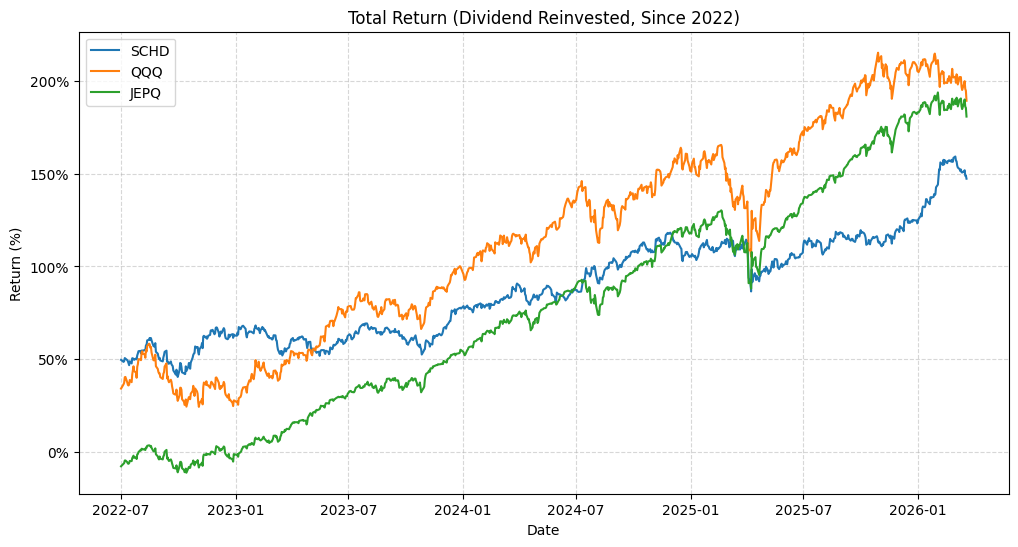

In [11]:
# Same period comparison (2022~)

same_period = cumulative_reinvested_return[
    cumulative_reinvested_return.index >= "2022-07-01"
]

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(12,6))

for etf in same_period.columns:
    plt.plot(
        same_period.index,
        same_period[etf] - 1,
        label=etf
    )

plt.title("Total Return (Dividend Reinvested, Since 2022)")
plt.xlabel("Date")
plt.ylabel("Return (%)")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("images/total_return_reinvested_2022.png")
plt.show()

## 🔍 Interpretation

When all ETFs are compared over the same period starting from 2022, the relative performance becomes clearer.

QQQ still achieves the highest total return, indicating that strong price appreciation remains the dominant driver of performance.

JEPQ shows strong performance and benefits significantly from dividend reinvestment, but it does not outperform QQQ when compared over the same time frame.

SCHD continues to demonstrate stable and consistent growth, although its total return remains lower than the other ETFs.

These results suggest that JEPQ’s strong performance in the full-period analysis was partly influenced by its shorter history and favorable market conditions.

This shows that even if the overall ranking appears similar, comparing ETFs over different time periods can lead to misleading interpretations.

Using the same time frame ensures that all assets are evaluated under identical market conditions, making the comparison more reliable and fair.